In [60]:
import pandas as pd

df = pd.read_csv("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

df["time:timestamp"] = pd.to_datetime(
    df["time:timestamp"],
    format="mixed",
    utc=True
)

df = df.sort_values(by=["case:concept:name", "time:timestamp"])

Số lượng Case trong log_full: 31509


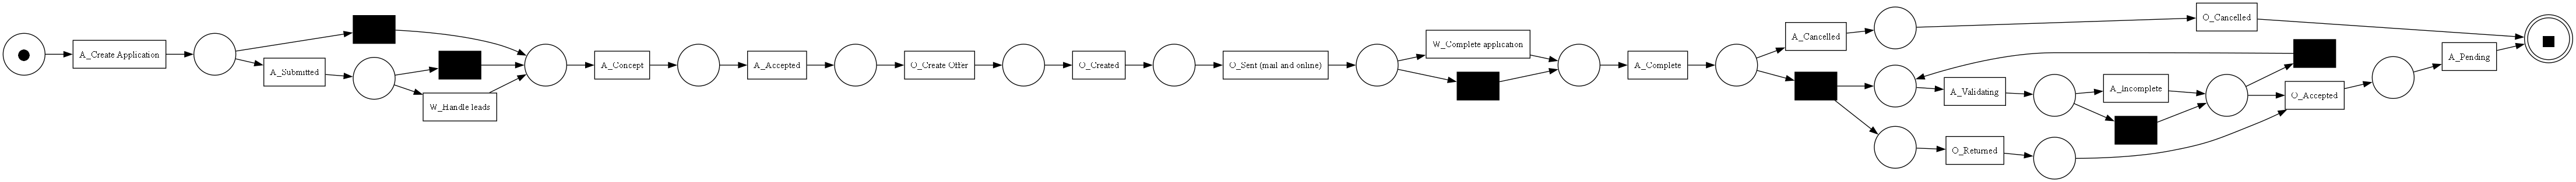

Số lượng hồ sơ (Cases): 31509


In [61]:
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

df_complete = df[df["lifecycle:transition"] == "complete"].copy()
log_full = pm4py.format_dataframe(
    df_complete, 
    case_id="case:concept:name", 
    activity_key="concept:name", 
    timestamp_key="time:timestamp"
)
log_full = log_converter.apply(log_full)
print(f"Số lượng Case trong log_full: {len(log_full)}")

top_10_variants_log = pm4py.filter_variants_top_k(log_full, k=10)

net, im, fm = pm4py.discover_petri_net_inductive(top_10_variants_log)

pm4py.view_petri_net(net, im, fm)
print("Số lượng hồ sơ (Cases):", df_complete['case:concept:name'].nunique())

In [ ]:
from pm4py.objects.log.obj import EventLog, Trace

n_steps = 5  # Bạn có thể giữ 5 hoặc 10
log_prefix_temp = EventLog()

for trace in log_full:
    # Lấy n sự kiện đầu tiên
    events_prefix = trace[:n_steps]
    
    # KHỞI TẠO Trace mới và đưa attributes vào ngay từ đầu
    # Cách này tránh việc dùng dấu '=' gây lỗi setter
    new_trace = Trace(events_prefix, attributes=trace.attributes)
    
    log_prefix_temp.append(new_trace)

alignments = pm4py.conformance_diagnostics_alignments(log_prefix_temp, net, im, fm)

alignment_results = []
for trace, align in zip(log_prefix_temp, alignments):
    case_id = trace.attributes['concept:name']
    
    alignment_results.append({
        "case:concept:name": case_id,
        "alignment_cost": align["cost"],
        "fitness": align["fitness"]
    })

df_alignment = pd.DataFrame(alignment_results)

print(f"Xử lý thành công Prefix {n_steps} cho {len(df_alignment)} cases.")

aligning log, completed variants :: 100%|██████████| 12/12 [00:00<00:00, 240.02it/s]

Xử lý thành công Prefix 5 cho 31509 cases.


# Sử dụng Alignment

In [66]:
def get_final_outcome(group):
    acts = set(group["concept:name"].values)
    if "A_Pending" in acts: return 1   # Success
    if "A_Denied" in acts: return 0    # Denied
    if "A_Cancelled" in acts: return 2 # Churn
    return -1

df_target = df_complete.groupby("case:concept:name").apply(get_final_outcome).reset_index()
df_target.columns = ["case:concept:name", "final_label"]
df_target = df_target[df_target["final_label"] != -1]

def extract_prefix_features(group, n=10):
    prefix = group.head(n)
    if len(prefix) < n: 
        return None 
    
    # Tính các đặc trưng dựa trên n hành động
    features = {
        # 1. Đặc trưng quy trình (Dynamic)
        "prefix_duration_days": (prefix["time:timestamp"].max() - prefix["time:timestamp"].min()).total_seconds() / 86400,
        "last_activity": prefix["concept:name"].iloc[-1],
        
        # 2. Biến tĩnh (Static - Có ngay từ đầu)
        "requested_amount": prefix["case:RequestedAmount"].iloc[0],
        "loan_goal": prefix["case:LoanGoal"].iloc[0],
        "app_type": prefix["case:ApplicationType"].iloc[0],
    }
    
    if 'CreditScore' in prefix.columns:
        score = prefix['CreditScore'].max()
        features["credit_score"] = score if pd.notnull(score) else 0
    else:
        features["credit_score"] = 0
        
    return pd.Series(features)

df_prefix = df_complete.groupby("case:concept:name").apply(extract_prefix_features, n=10).dropna().reset_index()

# Kiểm tra kết quả
print(df_prefix.head())

# Kết hợp cả đặc trưng Prefix, đặc trưng Alignment và Nhãn
train_df = df_prefix.merge(df_alignment, on="case:concept:name")
train_df = train_df.merge(df_target, on="case:concept:name")
outcome_activities = ["A_Pending", "A_Cancelled", "A_Denied", "O_Accepted", "O_Refused", "O_Cancelled"]

train_df = train_df[~train_df["last_activity"].isin(outcome_activities)]


# Chuyển đổi các biến phân loại sang số (One-Hot Encoding)
# Pandas sẽ tự động tạo các cột như loan_goal_Car, loan_goal_Home, v.v.
categorical_cols = ["last_activity", "loan_goal", "app_type"]
train_df_encoded = pd.get_dummies(train_df, columns=categorical_cols)

# Chuẩn bị X và y
# Loại bỏ các cột ID và nhãn để làm đầu vào X
X = train_df_encoded.drop(columns=["case:concept:name", "final_label"])
y = train_df_encoded["final_label"]


C:\Users\Admin\AppData\Local\Temp\ipykernel_6276\3125475235.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_target = df_complete.groupby("case:concept:name").apply(get_final_outcome).reset_index()


        case:concept:name  prefix_duration_days last_activity  \
0  Application_1000086665             32.585592   O_Cancelled   
1  Application_1000158214              6.986227  A_Validating   
2  Application_1000311556             30.586242   O_Cancelled   
3  Application_1000334415              5.894135  A_Validating   
4  Application_1000339879              5.804793  A_Validating   

   requested_amount               loan_goal    app_type  credit_score  
0            5000.0  Other, see explanation  New credit           0.0  
1           12500.0        Home improvement  New credit         929.0  
2           45000.0                     Car  New credit           0.0  
3            5000.0  Other, see explanation  New credit           0.0  
4           37500.0  Existing loan takeover  New credit         798.0  


C:\Users\Admin\AppData\Local\Temp\ipykernel_6276\3125475235.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_prefix = df_complete.groupby("case:concept:name").apply(extract_prefix_features, n=10).dropna().reset_index()


In [67]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Chia tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện model
model = xgb.XGBClassifier(
    objective="multi:softprob", 
    num_class=3, 
    n_estimators=100, 
    learning_rate=0.1
) 

model.fit(X_train, y_train)

# Đánh giá kết quả
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Denied", "Success", "Churn"]))

              precision    recall  f1-score   support

      Denied       0.58      0.61      0.60       654
     Success       0.97      0.89      0.93      3375
       Churn       0.57      0.77      0.66       730

    accuracy                           0.83      4759
   macro avg       0.71      0.76      0.73      4759
weighted avg       0.85      0.83      0.84      4759



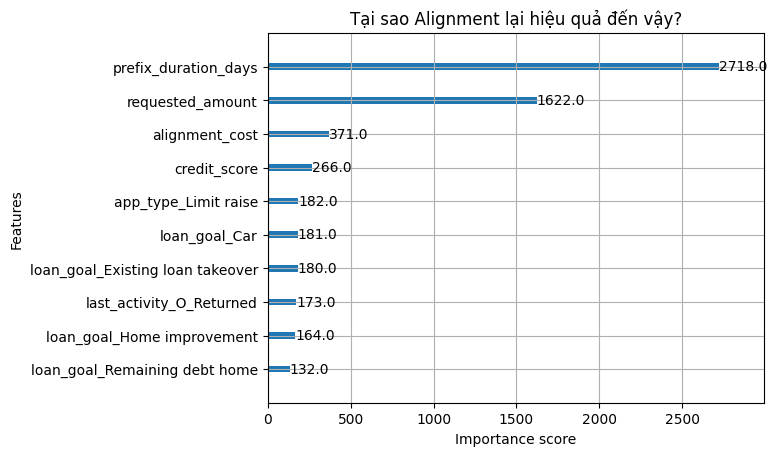

In [68]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=10)
plt.title("Tại sao Alignment lại hiệu quả đến vậy?")
plt.show()

# Train truyền thống

In [ ]:
import pandas as pd
import numpy as np

# 1. Hàm trích xuất đặc trưng truyền thống
def extract_traditional_features(group, n=10):
    prefix = group.head(n)
    if len(prefix) < n:
        return None
    
    # Lấy các sự kiện trong prefix để đếm
    activities = prefix["concept:name"].tolist()
    
    features = {
        # A. Đặc trưng ngữ cảnh (Static)
        "requested_amount": prefix["case:RequestedAmount"].iloc[0],
        "loan_goal": prefix["case:LoanGoal"].iloc[0],
        "app_type": prefix["case:ApplicationType"].iloc[0],
        
        # B. Đặc trưng thời gian (Temporal)
        "elapsed_time": (prefix["time:timestamp"].max() - prefix["time:timestamp"].min()).total_seconds() / 86400,
        "last_step_duration": 0 if n < 2 else (prefix["time:timestamp"].iloc[-1] - prefix["time:timestamp"].iloc[-2]).total_seconds() / 3600, # giờ
        
        # C. Đặc trưng quy trình (Control-flow)
        "current_activity": activities[-1],
        "event_count": len(prefix),
        # Đếm số lần xuất hiện của các bước quan trọng (Bag of Activities)
        "count_W_Call": activities.count("W_Call after offers"),
        "count_O_Created": activities.count("O_Created"),
        "count_A_Incomplete": activities.count("A_Incomplete")
    }
    return pd.Series(features)

# 2. Tạo tập dữ liệu Features
df_trad_features = df_complete.groupby("case:concept:name").apply(extract_traditional_features, n=10).dropna().reset_index()

# 3. Kết hợp với nhãn mục tiêu (df_target đã làm ở bước trước)
train_df = df_trad_features.merge(df_target, on="case:concept:name")

# 4. Tiền xử lý (One-Hot Encoding)
categorical_cols = ["loan_goal", "app_type", "current_activity"]
train_df_encoded = pd.get_dummies(train_df, columns=categorical_cols)

# Chuẩn bị X và y
X = train_df_encoded.drop(columns=["case:concept:name", "final_label"])
y = train_df_encoded["final_label"]

C:\Users\Admin\AppData\Local\Temp\ipykernel_6276\1418996390.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_trad_features = df_complete.groupby("case:concept:name").apply(extract_traditional_features, n=10).dropna().reset_index()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Cách truyền thống thường dùng Random Forest vì nó rất ổn định với dữ liệu bảng
model_trad = RandomForestClassifier(
    n_estimators=200, 
    class_weight="balanced",
    random_state=42
)

model_trad.fit(X_train, y_train)

y_pred = model_trad.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.12      0.18       743
           1       0.74      0.89      0.81      3446
           2       0.81      0.73      0.77      2009

    accuracy                           0.74      6198
   macro avg       0.65      0.58      0.59      6198
weighted avg       0.72      0.74      0.72      6198

